# Global Earthquakes M≥4.0

Reads from `quakes.sqlite`, populated by `fetch_quakes.py` (USGS FDSN catalog).

Pre-1965 data is sparse globally; treat earlier years as undercounting reality.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB = Path('quakes.sqlite')

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(
        'SELECT id, time_ms, mag, mag_type, lat, lon, depth_km, place '
        'FROM quakes ORDER BY time_ms',
        conn,
    )
df['time'] = pd.to_datetime(df['time_ms'], unit='ms', utc=True)
df['year'] = df['time'].dt.year
print(f'Loaded {len(df):,} events, {df["time"].min():%Y-%m-%d} → {df["time"].max():%Y-%m-%d}')
df.head()

Loaded 529,887 events, 1965-01-01 → 2026-05-08


,id,time_ms,mag,mag_type,lat,lon,depth_km,place,time,year
0,ci3330737,-157737342220,4.46,ml,34.129333,-117.5090,3.310,"6km NW of Fontana, CA",1965-01-01 08:04:17.780000+00:00,1965
1,hv19650001,-157712534480,4.11,ml,19.814333,-155.3875,24.017,"24 km SW of Laup?hoehoe, Hawaii",1965-01-01 14:57:45.520000+00:00,1965
2,iscgem860696,-157688488640,5.64,mw,35.703000,4.3910,12.400,"13 km W of M’sila, Algeria",1965-01-01 21:38:31.360000+00:00,1965
3,iscgem860706,-157630541080,5.98,mw,19.246000,145.6160,131.600,"Maug Islands region, Northern Mariana Islands",1965-01-02 13:44:18.920000+00:00,1965
4,iscgem860737,-157465810500,5.76,mw,1.863000,127.3520,80.000,"74 km WNW of Tobelo, Indonesia",1965-01-04 11:29:49.500000+00:00,1965


## Magnitude vs Time

Each dot is one earthquake. M≥7.0 events highlighted.

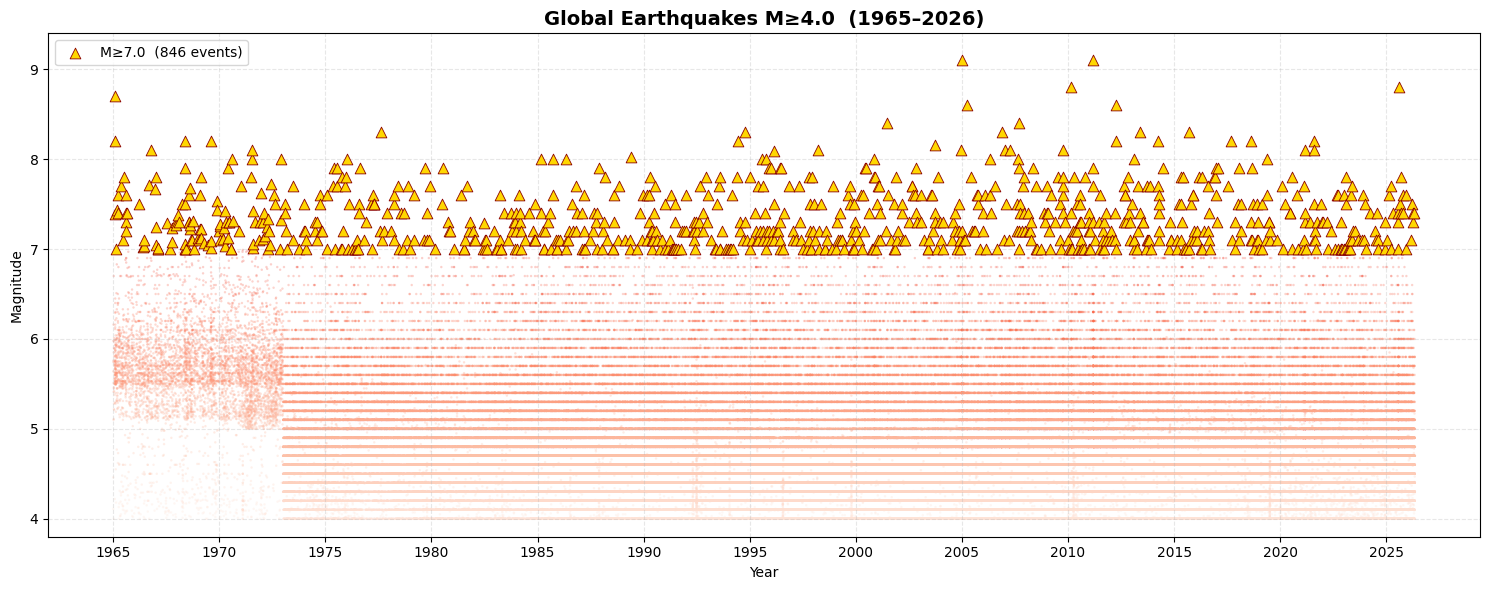

In [2]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(df['time'], df['mag'], c=df['mag'], cmap='Reds',
           alpha=0.25, s=3, linewidth=0)

major = df[df['mag'] >= 7.0]
ax.scatter(major['time'], major['mag'], c='gold', s=60, marker='^',
           edgecolors='darkred', linewidth=0.6, zorder=5,
           label=f'M≥7.0  ({len(major):,} events)')

ax.set_xlabel('Year')
ax.set_ylabel('Magnitude')
ax.set_title(f'Global Earthquakes M≥4.0  ({df["year"].min()}–{df["year"].max()})',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(3.8, df['mag'].max() + 0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Yearly Counts by Magnitude Band

Pre-1965 numbers undercount due to sparse global instrumentation. The visible step-up around 1965–1973 is mostly improved coverage, not more quakes.

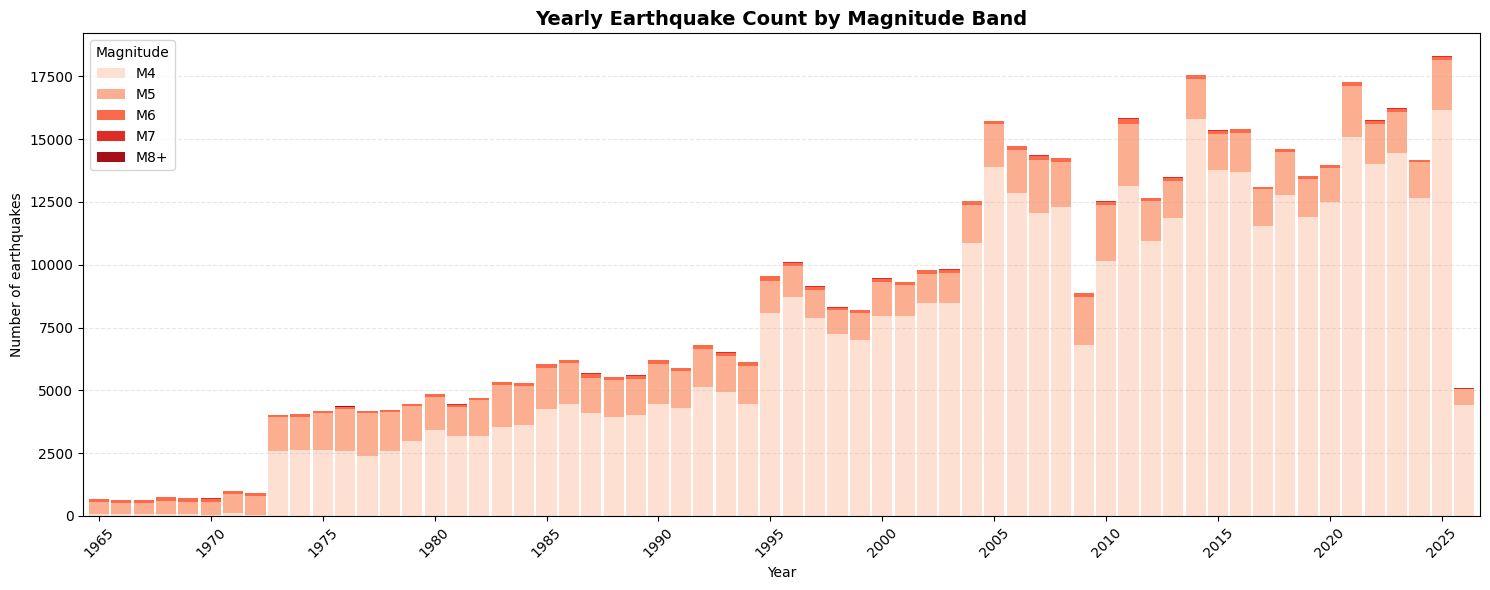

In [3]:
bands = [(4, 5, 'M4'), (5, 6, 'M5'), (6, 7, 'M6'), (7, 8, 'M7'), (8, 11, 'M8+')]
by_year = pd.DataFrame({'year': sorted(df['year'].unique())}).set_index('year')
for lo, hi, label in bands:
    sel = df[(df['mag'] >= lo) & (df['mag'] < hi)]
    by_year[label] = sel.groupby('year').size()
by_year = by_year.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(15, 6))
by_year.plot(kind='bar', stacked=True, ax=ax, width=0.9,
             color=['#fee0d2', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'])
ax.set_xlabel('Year')
ax.set_ylabel('Number of earthquakes')
ax.set_title('Yearly Earthquake Count by Magnitude Band',
             fontsize=14, fontweight='bold')
ax.legend(title='Magnitude', loc='upper left')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ticks = ax.get_xticks()
ax.set_xticks(ticks[::5])
ax.set_xticklabels(by_year.index[::5], rotation=45)
plt.tight_layout()
plt.show()

## Magnitude Distribution

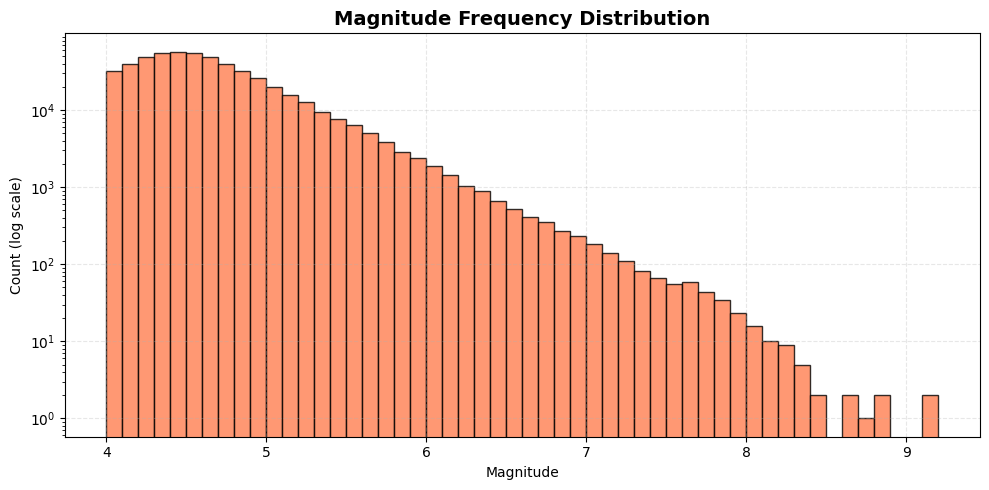

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['mag'], bins=np.arange(4.0, df['mag'].max() + 0.2, 0.1),
        color='coral', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count (log scale)')
ax.set_title('Magnitude Frequency Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Stats

In [5]:
print(f'Total events:       {len(df):,}')
print(f'Date range:         {df["time"].min():%Y-%m-%d}  →  {df["time"].max():%Y-%m-%d}')
print(f'Magnitude range:    {df["mag"].min():.1f}  →  {df["mag"].max():.1f}')
print(f'Years covered:      {df["year"].nunique()}')
print()
print('Counts by magnitude band:')
for lo, hi, label in bands:
    n = ((df['mag'] >= lo) & (df['mag'] < hi)).sum()
    print(f'  {label:5s}  {n:>9,}')
print()
print('Top 10 largest events:')
top = df.nlargest(10, 'mag')[['time', 'mag', 'place']]
for _, row in top.iterrows():
    print(f'  {row["time"]:%Y-%m-%d}  M{row["mag"]:.1f}  {row["place"]}')

Total events:       529,887
Date range:         1965-01-01  →  2026-05-08
Magnitude range:    3.4  →  9.1
Years covered:      62

Counts by magnitude band:
  M4       435,371
  M5        85,992
  M6         7,677
  M7           797
  M8+           49

Top 10 largest events:
  2004-12-26  M9.1  2004 Sumatra - Andaman Islands Earthquake
  2011-03-11  M9.1  2011 Great Tohoku Earthquake, Japan
  2010-02-27  M8.8  2010 Maule, Chile Earthquake
  2025-07-29  M8.8  2025 Kamchatka Peninsula, Russia Earthquake
  1965-02-04  M8.7  1965 Western Aleutian Islands (Hawadax/Rat Islands) Earthquake
  2005-03-28  M8.6  78 km WSW of Singkil, Indonesia
  2012-04-11  M8.6  2012 Wharton Basin Earthquake
  2001-06-23  M8.4  6 km SSW of Atico, Peru
  2007-09-12  M8.4  122 km SW of Bengkulu, Indonesia
  1977-08-19  M8.3  1977 Sumba, Indonesia Earthquake
